# Phase 2 - Regime Engine

Turns the Phase 1 daily panel into the **historical regime database**.

Pipeline (all point-in-time, no lookahead):
1. **Score 3 axes** -> bucket each day.
   - **Inventory** (`eia_crude_stocks_seas_z`, deviation from seasonal norm): H / M / L by **expanding terciles**.
   - **Volatility** (`rv_c1`): H / M / L by expanding terciles.
   - **Curve** (`slope_pct`): Backwardation / Contango / **Flat** via a dead-band (expanding quantile of |slope|).
2. **27 labels** = inventory x volatility x curve.
3. **Min-N merge**: cells with < `MIN_N` train obs collapse to a coarser *effective regime* (drop volatility first, then curve, then global). Structure decided on **train only**.
4. **Distance-to-boundary** + low-confidence flag; **flicker** check.
5. Persist `cache/CL_regimes.parquet`.

Terciles use **expanding** windows (history up to and including day *t*), so a day is classified with only what was knowable then. Merge structure is frozen from the training period.

In [1]:
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 60)

CACHE = Path("cache")
INSTRUMENT = "CL"
MIN_N   = 60      # booklet lower bound for a fittable cell
WARMUP  = 252     # ~1y before we trust tercile cuts

p = pd.read_parquet(CACHE / f"{INSTRUMENT}_daily_panel.parquet").sort_index()
train = p["split"] == "train"
print("rows:", len(p), "| train:", int(train.sum()), "| test:", int((~train).sum()))
p[["eia_crude_stocks_seas_z","rv_c1","slope_pct","split"]].tail(3)

rows: 1659 | train: 1590 | test: 69


,eia_crude_stocks_seas_z,rv_c1,slope_pct,split
date,,,,
2026-05-20,-0.365787,0.001664,0.044551,test
2026-05-21,-0.360280,0.001225,0.034537,test
2026-05-22,-0.355015,0.000702,0.035244,test


## 1. Axis scoring (point-in-time)

`expanding_tercile` returns H/M/L using boundaries computed from data up to each day. Inventory falls back to the raw stock level on the early days where the seasonal-z has no history yet.

In [2]:
SMOOTH = 5      # trailing days to smooth axis inputs (purely backward-looking)
HYST   = 0.15   # hysteresis buffer as a fraction of the tercile gap

def expanding_terciles(s):
    q1 = s.expanding(min_periods=WARMUP).quantile(1/3)
    q2 = s.expanding(min_periods=WARMUP).quantile(2/3)
    return q1, q2

def hysteretic_tercile(s, q1, q2, frac=HYST, hi="H", mid="M", lo="L"):
    """Bucket H/M/L but only switch once the value clears the cut by a buffer."""
    buf = (q2 - q1) * frac
    out = []; prev = None
    for v, a, b, bf in zip(s.values, q1.values, q2.values, buf.values):
        if np.isnan(a) or np.isnan(v):
            out.append(np.nan); continue
        if prev is None:
            cur = lo if v <= a else (mid if v <= b else hi)
        elif prev == lo:
            cur = lo
            if v > a + bf: cur = mid if v <= b else hi
        elif prev == mid:
            cur = mid
            if v < a - bf: cur = lo
            elif v > b + bf: cur = hi
        else:  # prev == hi
            cur = hi
            if v < b - bf: cur = lo if v < a - bf else mid
        out.append(cur); prev = cur
    return pd.Series(out, index=s.index)

# --- smoothed, backward-looking axis inputs ---
inv_raw = p["eia_crude_stocks_seas_z"].fillna(p["eia_crude_stocks"].rank(pct=True))
inv_s   = inv_raw.rolling(SMOOTH, min_periods=1).mean()
vol_s   = p["rv_c1"].rolling(SMOOTH, min_periods=1).mean()
slope_s = p["slope_pct"].rolling(SMOOTH, min_periods=1).mean()
absslope = slope_s.abs()

inv_q1, inv_q2 = expanding_terciles(inv_s)
vol_q1, vol_q2 = expanding_terciles(vol_s)
inv_lab = hysteretic_tercile(inv_s, inv_q1, inv_q2)
vol_lab = hysteretic_tercile(vol_s, vol_q1, vol_q2)

# --- curve axis: dead-band on |smoothed slope| with hysteresis around Flat ---
band = absslope.expanding(min_periods=WARMUP).quantile(1/3)
curve_lab = []; prev = None
for v, a, bd in zip(slope_s.values, absslope.values, band.values):
    if np.isnan(bd) or np.isnan(v):
        curve_lab.append(np.nan); continue
    if prev == "Flat":
        cur = "Flat" if a <= bd*(1+HYST) else ("Back" if v > 0 else "Contango")
    else:
        cur = "Flat" if a <= bd*(1-HYST) else ("Back" if v > 0 else "Contango")
    curve_lab.append(cur); prev = cur
curve_lab = pd.Series(curve_lab, index=p.index)

axes = pd.DataFrame({"inv": inv_lab, "vol": vol_lab, "curve": curve_lab}).dropna()
print("after warmup:", len(axes), "days")
for c in axes: print(c, dict(axes[c].value_counts()))

after warmup: 1408 days
inv {'L': np.int64(594), 'M': np.int64(438), 'H': np.int64(376)}
vol {'L': np.int64(516), 'M': np.int64(448), 'H': np.int64(444)}
curve {'Back': np.int64(1023), 'Flat': np.int64(349), 'Contango': np.int64(36)}


## 2. The 27 labels

In [3]:
regime_full = axes["inv"] + "|" + axes["vol"] + "|" + axes["curve"]
regime_full.name = "regime_full"
tr = train.reindex(axes.index, fill_value=False)
counts_full = regime_full[tr].value_counts()
print("distinct regimes seen in train:", counts_full.size, "of 27 possible")
print("\nsparse cells (train count <", MIN_N, "):",
      int((counts_full < MIN_N).sum()))
counts_full

distinct regimes seen in train: 21 of 27 possible

sparse cells (train count < 60 ): 12


regime_full
L|H|Back        193
L|M|Back        172
M|L|Back        162
L|L|Back        151
M|H|Back         75
H|M|Flat         73
M|M|Flat         70
H|L|Back         68
H|L|Flat         63
M|M|Back         55
H|M|Back         44
L|L|Flat         38
H|H|Back         35
M|L|Flat         30
L|H|Flat         27
M|H|Flat         21
H|M|Contango     21
H|H|Flat         13
L|M|Flat         13
H|H|Contango     11
H|L|Contango      4
Name: count, dtype: int64

## 3. Min-N merge -> effective regimes

Structure is decided on **train counts only**. For each full triple we pick the *finest* level that has >= `MIN_N` train observations:

`inv|vol|curve` -> `inv|*|curve` (drop vol) -> `inv|*|*` (drop curve) -> `ALL` (global).

In [4]:
def lvl_counts(keys):
    s = pd.Series(keys, index=axes.index)
    return s, s[tr].value_counts()

l0 = regime_full
l1 = axes["inv"] + "|*|" + axes["curve"]
l2 = axes["inv"] + "|*|*"
_, c0 = lvl_counts(l0); _, c1 = lvl_counts(l1); _, c2 = lvl_counts(l2)

def effective(i):
    k0, k1, k2 = l0[i], l1[i], l2[i]
    if c0.get(k0,0) >= MIN_N: return k0, 0
    if c1.get(k1,0) >= MIN_N: return k1, 1
    if c2.get(k2,0) >= MIN_N: return k2, 2
    return "ALL", 3

eff = [effective(i) for i in axes.index]
regime_eff = pd.Series([e[0] for e in eff], index=axes.index, name="regime_eff")
regime_lvl = pd.Series([e[1] for e in eff], index=axes.index, name="regime_level")

print("effective regimes:", regime_eff.nunique())
print("level usage (0=full..3=global):", dict(regime_lvl.value_counts().sort_index()))
print("\neffective regime train counts:")
print(regime_eff[tr].value_counts())

effective regimes: 15
level usage (0=full..3=global): {0: np.int64(1051), 1: np.int64(321), 2: np.int64(36)}

effective regime train counts:
regime_eff
L|H|Back    193
L|M|Back    172
M|L|Back    162
L|L|Back    151
H|*|Back     79
L|*|Flat     78
M|H|Back     75
H|M|Flat     73
M|M|Flat     70
H|L|Back     68
H|L|Flat     63
M|*|Back     55
M|*|Flat     51
H|*|*        36
H|*|Flat     13
Name: count, dtype: int64


## 4. Distance-to-boundary & flicker

In [5]:
# per-axis distance to nearest cut, scaled by expanding std -> confidence flag
def axis_dist(val, q1, q2):
    d = pd.concat([(val-q1).abs(), (val-q2).abs()], axis=1).min(axis=1)
    sd = val.expanding(min_periods=WARMUP).std()
    return d / sd
inv_d = axis_dist(inv_s, inv_q1, inv_q2).reindex(axes.index)
vol_d = axis_dist(vol_s, vol_q1, vol_q2).reindex(axes.index)
cur_d = ((absslope - band).abs() / absslope.expanding(min_periods=WARMUP).std()).reindex(axes.index)
boundary_dist = pd.concat([inv_d, vol_d, cur_d], axis=1).min(axis=1)

# calibrate flag to the closest ~20% of days (expanding -> point-in-time)
thr = boundary_dist.expanding(min_periods=WARMUP).quantile(0.20)
near_boundary = boundary_dist < thr

flicker = (regime_eff != regime_eff.shift()).mean()
print(f"near-boundary days: {near_boundary.mean():.1%}")
print(f"day-to-day regime change (flicker): {flicker:.1%}")

near-boundary days: 17.9%
day-to-day regime change (flicker): 12.6%


## 5. Assemble & persist the regime database

In [6]:
reg = p.join(pd.DataFrame({
    "inv": axes["inv"], "vol": axes["vol"], "curve": axes["curve"],
    "regime_full": regime_full, "regime_eff": regime_eff,
    "regime_level": regime_lvl, "boundary_dist": boundary_dist,
    "near_boundary": near_boundary,
}), how="inner")
out = CACHE / f"{INSTRUMENT}_regimes.parquet"
reg.to_parquet(out)
print("saved:", out, "| rows:", len(reg))
print("\ncols:", [c for c in reg.columns if c in
      ['inv','vol','curve','regime_full','regime_eff','regime_level','boundary_dist','near_boundary']])
reg[["inv","vol","curve","regime_eff","regime_level","near_boundary","split"]].tail(5)

saved: cache\CL_regimes.parquet | rows: 1408

cols: ['inv', 'vol', 'curve', 'regime_full', 'regime_eff', 'regime_level', 'boundary_dist', 'near_boundary']


,inv,vol,curve,regime_eff,regime_level,near_boundary,split
date,,,,,,,
2026-05-18,H,H,Back,H|*|Back,1,False,test
2026-05-19,H,H,Back,H|*|Back,1,False,test
2026-05-20,M,H,Back,M|H|Back,0,False,test
2026-05-21,M,H,Back,M|H|Back,0,False,test
2026-05-22,M,H,Back,M|H|Back,0,False,test


## 6. Sanity: regime timeline & spread coloured by regime

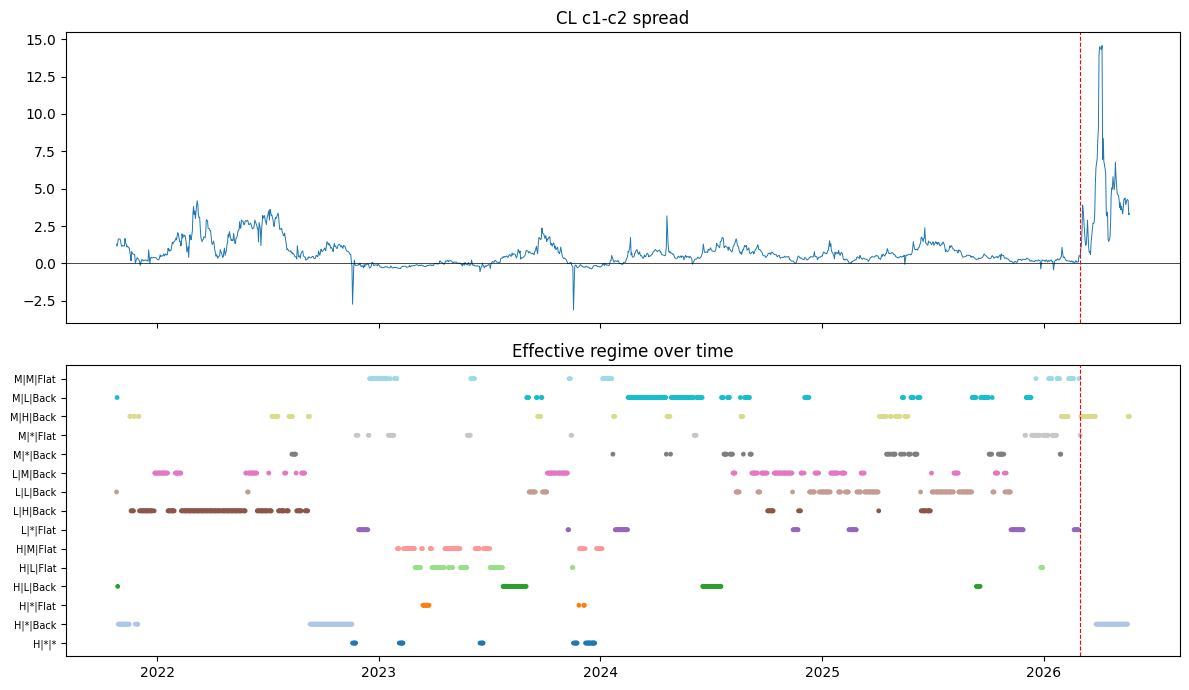

,n,mean_spread,mean_rv,mean_invz
regime_eff,,,,
L|H|Back,193,1.524,0.001,-1.319
L|M|Back,172,0.866,0.001,-1.159
M|L|Back,162,0.629,0.000,-0.200
L|L|Back,151,0.783,0.000,-0.977
H|*|Back,79,0.927,0.001,1.273
L|*|Flat,78,0.088,0.001,-0.996
M|H|Back,75,0.905,0.001,-0.599
H|M|Flat,73,-0.115,0.001,0.726
M|M|Flat,70,-0.029,0.001,-0.427


In [7]:
fig, ax = plt.subplots(2,1, figsize=(12,7), sharex=True)
ax[0].plot(reg.index, reg["cal_1_2"], lw=.7); ax[0].axhline(0,color="k",lw=.5)
ax[0].set_title("CL c1-c2 spread")
codes = reg["regime_eff"].astype("category").cat.codes
sc = ax[1].scatter(reg.index, codes, c=codes, cmap="tab20", s=6)
ax[1].set_yticks(range(reg["regime_eff"].nunique()))
ax[1].set_yticklabels(reg["regime_eff"].astype("category").cat.categories, fontsize=7)
ax[1].set_title("Effective regime over time")
for a in ax: a.axvline(pd.Timestamp("2026-03-01"), color="r", ls="--", lw=.8)
plt.tight_layout(); plt.show()

# avg spread & vol per effective regime (train) - economic sanity
summ = reg[reg.split=="train"].groupby("regime_eff").agg(
    n=("cal_1_2","size"), mean_spread=("cal_1_2","mean"),
    mean_rv=("rv_c1","mean"), mean_invz=("eia_crude_stocks_seas_z","mean")).round(3)
summ.sort_values("n", ascending=False)